#  Buyer Intent & Lead Scoring: Predicting Which Visitors Will Convert

**One-line summary:** Using 12,000+ real shopper sessions, I built an ML model that scores every visit by purchase intent, segmented visitors by behaviour, and turned the results into a Hot / Warm / Cold lead scorecard with product recommendations.

| | |
|---|---|
| **Problem** | Most visits never convert (~84%). Which visitors are worth prioritising, and why? |
| **Data** | UCI *Online Shoppers Purchasing Intention* dataset, 12,330 real browsing sessions, 17 behavioural features, label = purchase or not |
| **ML used** | Logistic Regression, Random Forest, Gradient Boosting (supervised) · K-Means (unsupervised) · Permutation importance (explainability) |
| **Output** | Intent score + tier + plain-English reasons per session, and a product roadmap |
| **Tools** | Python, Pandas, Scikit-learn, Seaborn, Matplotlib, Google Colab |


A marketplace's core product problem is the same: **thousands of buyers browse, only some are ready to enquire or buy.** Scoring buyer intent lets a platform route high-intent buyers to the right sellers faster, send better leads (higher seller satisfaction and renewals), and spend less effort nudging buyers who will never convert. This notebook uses a retail dataset as a proxy for that problem.



## 1. Setup and load the data

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.cluster import KMeans
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, average_precision_score, recall_score, precision_score,
                             roc_curve, precision_recall_curve)

sns.set_theme(style="whitegrid", context="notebook", font_scale=1.05)
TEAL, ORANGE, GREY, NAVY = "#1f9e89", "#f4743b", "#9aa5b1", "#264653"
pd.set_option("display.max_columns", 30)

In [2]:
# Source: UCI Machine Learning Repository, "Online Shoppers Purchasing Intention Dataset" (id 468)
URL = "https://raw.githubusercontent.com/sidneykung/online_shopper_intentions/main/data/online_shoppers_intention.csv"
try:
    df_raw = pd.read_csv(URL)
except Exception:
    # Fallback: official UCI loader
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ucimlrepo"])
    from ucimlrepo import fetch_ucirepo
    r = fetch_ucirepo(id=468)
    df_raw = pd.concat([r.data.features, r.data.targets], axis=1)

print("Rows, columns:", df_raw.shape)
df_raw.head()

Rows, columns: (12330, 18)


,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


### Data dictionary (what the columns mean)
| Column | Meaning |
|---|---|
| `Administrative`, `Informational`, `ProductRelated` (+ `_Duration`) | Number of pages visited in each page category, and seconds spent on them |
| `BounceRates` | % of visitors who enter the site and leave without any further action |
| `ExitRates` | % of page views that were the last in the session |
| `PageValues` | Average value of the pages a visitor saw before a purchase (a Google Analytics e-commerce metric) |
| `SpecialDay` | Closeness of the visit to a special day such as Valentine's Day (0 to 1) |
| `Month`, `Weekend` | When the visit happened |
| `VisitorType` | New, Returning or Other visitor |
| `OperatingSystems`, `Browser`, `Region`, `TrafficType` | Technical and acquisition-channel codes |
| **`Revenue`** | **Target: did the session end in a purchase?** |

*Source: Sakar, C.O., Polat, S.O., Katircioglu, M., Kastro, Y. (2019). Real-time prediction of online shoppers' purchasing intention using multilayer perceptron and LSTM recurrent neural networks. Neural Computing and Applications, 31, 6893-6908.*

## 2. Data quality checks and cleaning

In [3]:
checks = pd.Series({
    "Rows": len(df_raw),
    "Missing values": int(df_raw.isna().sum().sum()),
    "Exact duplicate rows": int(df_raw.duplicated().sum()),
    "Conversion rate (raw)": f"{df_raw['Revenue'].mean():.2%}",
})
print(checks.to_string())

df = df_raw.drop_duplicates().reset_index(drop=True)
df["Revenue"] = df["Revenue"].astype(int)
df["Weekend"] = df["Weekend"].astype(int)

# Feature engineering (simple, explainable)
df["TotalPages"] = df["Administrative"] + df["Informational"] + df["ProductRelated"]
df["TotalDuration"] = df["Administrative_Duration"] + df["Informational_Duration"] + df["ProductRelated_Duration"]
df["AvgTimePerPage"] = (df["TotalDuration"] / df["TotalPages"].replace(0, np.nan)).fillna(0)
df["IsReturning"] = (df["VisitorType"] == "Returning_Visitor").astype(int)

MONTH_ORDER = ["Feb", "Mar", "May", "June", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
BASE = df["Revenue"].mean()
print(f"\nAfter cleaning: {len(df):,} sessions | conversion rate {BASE:.2%}")

Rows                      12330
Missing values                0
Exact duplicate rows        125
Conversion rate (raw)    15.47%

After cleaning: 12,205 sessions | conversion rate 15.63%


### Notes
- **No missing values**, but **125 exact duplicate sessions** were removed, leaving 12,205 sessions.
- Added four simple features: **total pages, total time, average time per page** and a **returning-visitor flag**.
- Conversion rate is about **15.6%**, so the classes are imbalanced. That is why we will judge models with **PR-AUC and recall**, not accuracy alone (a model that always says "no purchase" would be 84% "accurate" and useless).

## 3. What drives conversion? (Exploratory analysis)

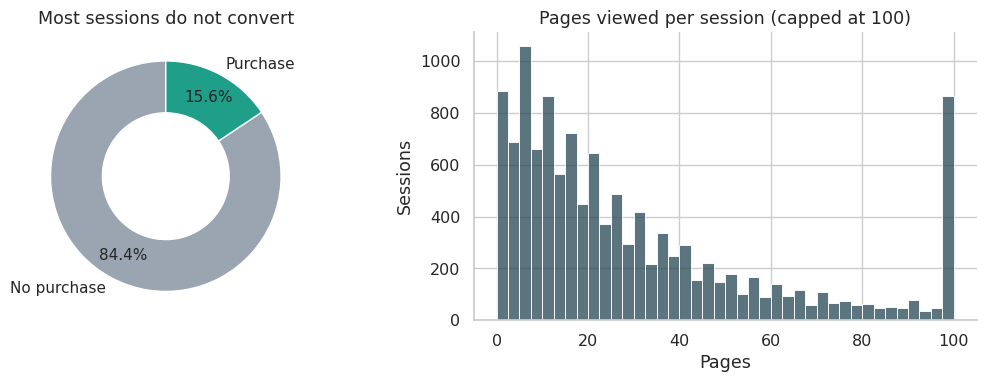

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

counts = df["Revenue"].map({0: "No purchase", 1: "Purchase"}).value_counts()
axes[0].pie(counts.values, labels=counts.index, autopct="%1.1f%%", startangle=90, pctdistance=0.78, textprops={"fontsize": 11},
            colors=[GREY, TEAL], wedgeprops=dict(width=0.45, edgecolor="white"))
axes[0].set_title("Most sessions do not convert")

sns.histplot(df["TotalPages"].clip(upper=100), bins=40, color=NAVY, ax=axes[1])
axes[1].set_title("Pages viewed per session (capped at 100)")
axes[1].set_xlabel("Pages"); axes[1].set_ylabel("Sessions")
sns.despine(); plt.tight_layout(); plt.show()

### What we can see
Only about **1 in 6 sessions converts**, and most sessions are short. This is the lead-quality problem in one picture: a few sessions carry most of the value, so **finding them early is the product opportunity.**

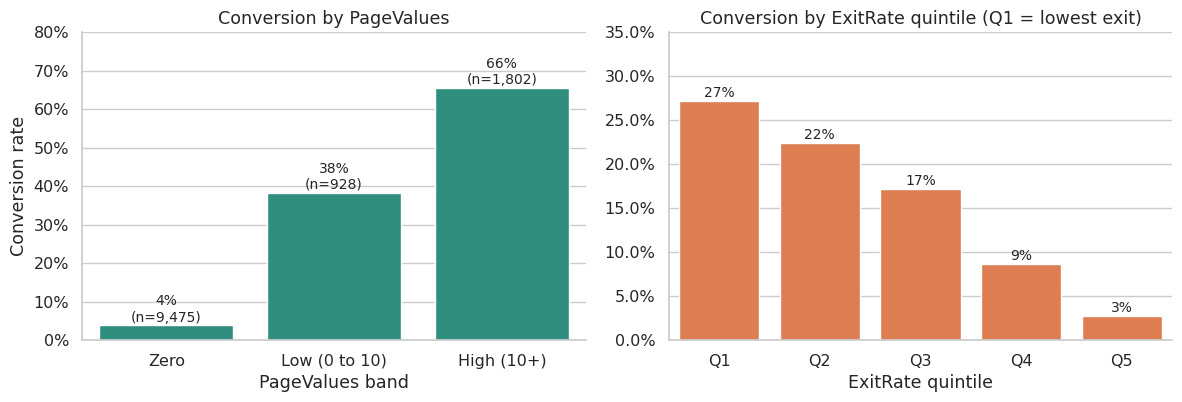

In [5]:
pv_bins = pd.cut(df["PageValues"], [-1, 0, 10, 1000], labels=["Zero", "Low (0 to 10)", "High (10+)"])
pv = df.groupby(pv_bins, observed=True)["Revenue"].agg(["mean", "size"])

exit_bins = pd.qcut(df["ExitRates"], 5, duplicates="drop")
ex = df.groupby(exit_bins, observed=True)["Revenue"].mean()
ex.index = [f"Q{i+1}" for i in range(len(ex))]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))
sns.barplot(x=pv.index, y=pv["mean"], color=TEAL, ax=axes[0])
axes[0].set_title("Conversion by PageValues"); axes[0].set_xlabel("PageValues band"); axes[0].set_ylabel("Conversion rate")
for i, (m, n) in enumerate(zip(pv["mean"], pv["size"])):
    axes[0].text(i, m + 0.01, f"{m:.0%}\n(n={n:,})", ha="center", fontsize=10)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); axes[0].set_ylim(0, 0.8)

sns.barplot(x=ex.index, y=ex.values, color=ORANGE, ax=axes[1])
axes[1].set_title("Conversion by ExitRate quintile (Q1 = lowest exit)"); axes[1].set_xlabel("ExitRate quintile"); axes[1].set_ylabel("")
for i, m in enumerate(ex.values):
    axes[1].text(i, m + 0.005, f"{m:.0%}", ha="center", fontsize=10)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); axes[1].set_ylim(0, 0.35)
sns.despine(); plt.tight_layout(); plt.show()

### What we see here
- **PageValues is the strongest signal.** Sessions with zero PageValues (about 78% of all sessions) convert at only **~4%**, while sessions with high PageValues convert at **~66%**.
- **Exit rate works the other way:** the lowest-exit visitors convert at about **27%**, the highest-exit visitors at about **3%**. Visitors who keep browsing are the ones who buy.

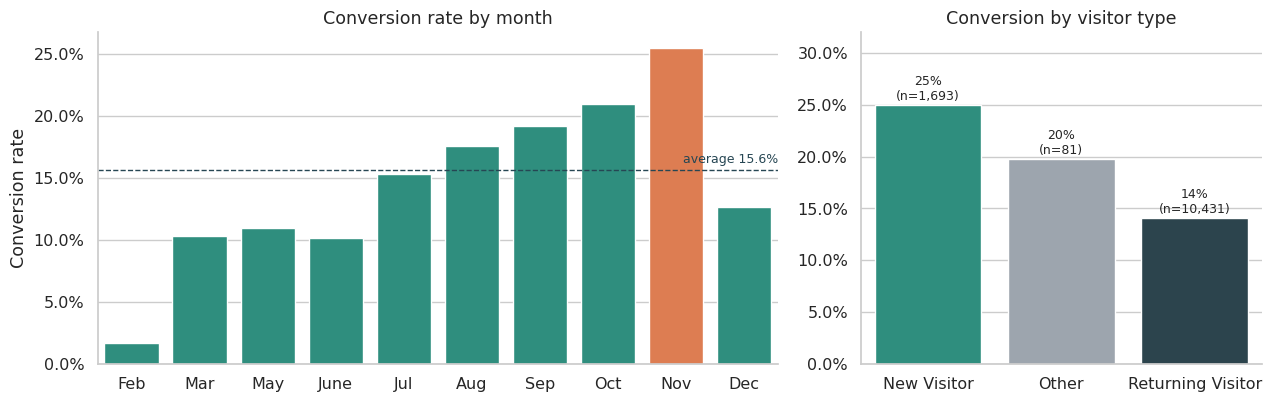

In [6]:
mon = df.groupby("Month")["Revenue"].agg(["mean", "size"]).reindex(MONTH_ORDER)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), gridspec_kw={"width_ratios": [1.7, 1]})

colors = [ORANGE if m == "Nov" else TEAL for m in mon.index]
sns.barplot(x=mon.index, y=mon["mean"], palette=colors, ax=axes[0])
axes[0].axhline(BASE, color=NAVY, ls="--", lw=1); axes[0].text(len(mon) - 0.5, BASE + 0.006, f"average {BASE:.1%}", ha="right", color=NAVY, fontsize=9)
axes[0].set_title("Conversion rate by month"); axes[0].set_xlabel(""); axes[0].set_ylabel("Conversion rate")
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

vt = df.groupby("VisitorType")["Revenue"].agg(["mean", "size"]).sort_values("mean", ascending=False)
sns.barplot(x=vt.index.str.replace("_", " "), y=vt["mean"], palette=[TEAL, GREY, NAVY], ax=axes[1])
axes[1].set_title("Conversion by visitor type"); axes[1].set_xlabel(""); axes[1].set_ylabel("")
for i, (m, n) in enumerate(zip(vt["mean"], vt["size"])):
    axes[1].text(i, m + 0.005, f"{m:.0%}\n(n={n:,})", ha="center", fontsize=9)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); axes[1].set_ylim(0, 0.32)
sns.despine(); plt.tight_layout(); plt.show()

### What we see
- **Seasonality is strong:** November converts at about **25.5%**, far above the 15.6% average (pre-holiday sales), while February is under 2% (but with only 181 sessions, so treat it with caution).
- **New visitors convert more than returning visitors** (about 25% vs 14%). Returning visitors are the bulk of traffic and include many just-browsing or comparison sessions. For a marketplace, that suggests *returning browsers* are where nudges and better matching can add the most value.

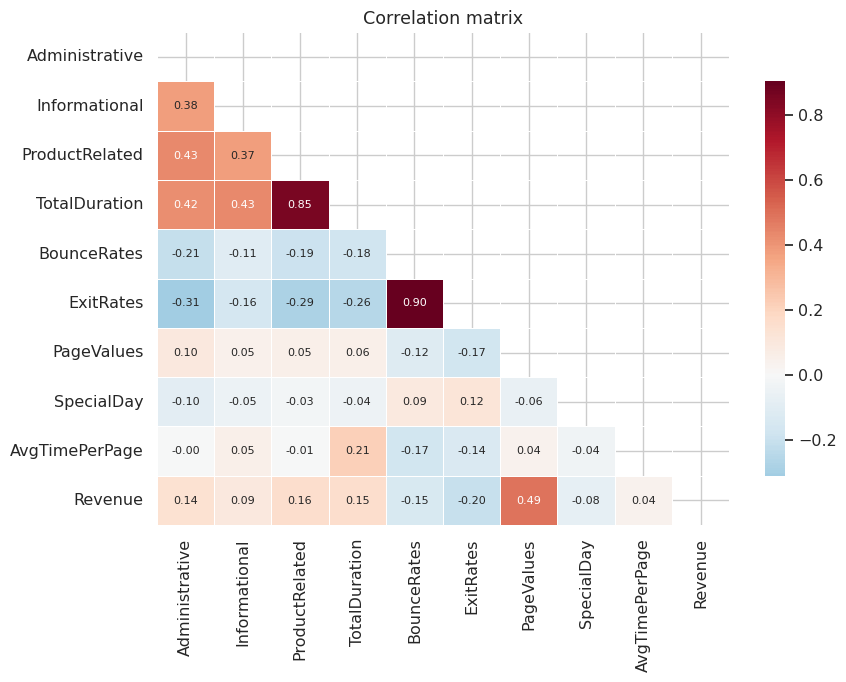

In [7]:
num_cols = ["Administrative", "Informational", "ProductRelated", "TotalDuration", "BounceRates",
            "ExitRates", "PageValues", "SpecialDay", "AvgTimePerPage", "Revenue"]
corr = df[num_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, mask=np.triu(np.ones_like(corr, dtype=bool)), cmap="RdBu_r", center=0, annot=True,
            fmt=".2f", annot_kws={"size": 8}, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation matrix"); plt.tight_layout(); plt.show()

### What we see
- `PageValues` has by far the strongest positive correlation with `Revenue` (about **+0.49**); `ExitRates` and `BounceRates` are negative.
- `BounceRates` and `ExitRates` are almost the same signal (correlation about **0.9**), so they carry overlapping information.
- **Caveat:** `PageValues` is computed from sessions that *ended in a transaction*, so in a live system it would only be available if it is derived from past data and not from the current session's outcome.This is flagged in the limitations.

## 4. Who are our visitors? (Unsupervised segmentation with K-Means)

In [8]:
seg_feats = ["Administrative", "Informational", "ProductRelated", "TotalDuration", "BounceRates", "ExitRates"]
Z = df[seg_feats].copy()
for c in ["Administrative", "Informational", "ProductRelated", "TotalDuration"]:
    Z[c] = np.log1p(Z[c])
Z = StandardScaler().fit_transform(Z)

km = KMeans(n_clusters=4, n_init=10, random_state=42).fit(Z)
df["cluster"] = km.labels_

prof = df.groupby("cluster").agg(sessions=("Revenue", "size"), conversion=("Revenue", "mean"),
                                 pages=("TotalPages", "mean"), minutes=("TotalDuration", lambda s: s.mean() / 60),
                                 exit_rate=("ExitRates", "mean"), page_value=("PageValues", "mean"))

# Name segments from their behaviour (data-driven, so names stay correct if clusters re-order)
def name_seg(r):
    depth = "Deep browsers" if r.pages > 1.6 * df["TotalPages"].mean() else ("Light visitors" if r.pages < 0.7 * df["TotalPages"].mean() else "Moderate browsers")
    exit_ = "low exit" if r.exit_rate < 0.7 * df["ExitRates"].mean() else ("high exit" if r.exit_rate > 1.3 * df["ExitRates"].mean() else "avg exit")
    return f"{depth} · {exit_}"
prof["segment"] = prof.apply(name_seg, axis=1)
prof = prof.sort_values("conversion", ascending=False)
prof.round(3)

,sessions,conversion,pages,minutes,exit_rate,page_value,segment
cluster,,,,,,,
1,2171,0.244,77.519,52.170,0.022,8.515,Deep browsers · low exit
0,4882,0.204,43.417,26.595,0.020,8.213,Moderate browsers · low exit
2,4436,0.086,9.940,5.839,0.050,3.163,Light visitors · avg exit
3,716,0.004,2.127,0.298,0.192,0.000,Light visitors · high exit


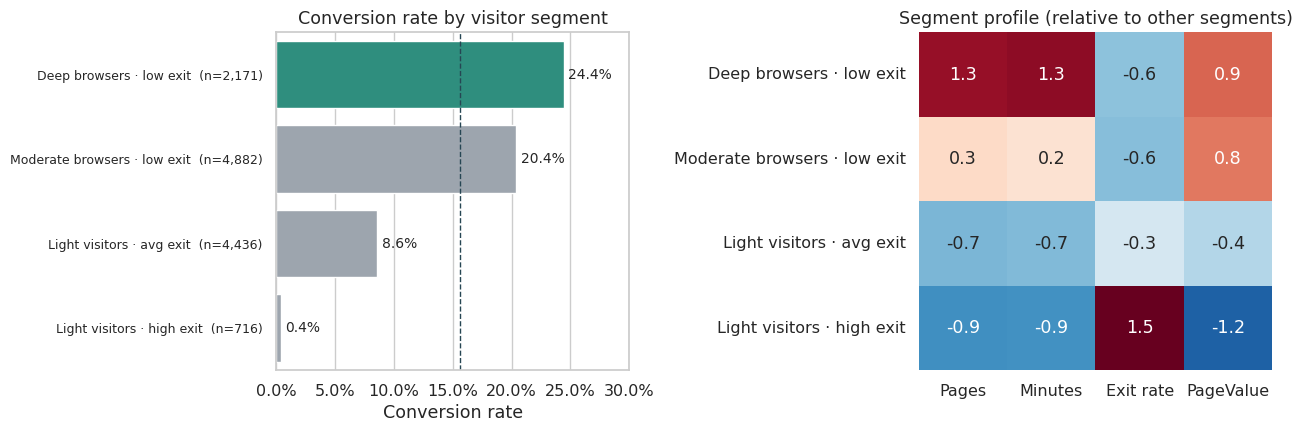

💡 Best segment: 'Deep browsers · low exit' converts at 24.4% vs 0.4% for 'Light visitors · high exit' (58.3x difference).


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
order = prof.index.tolist()
labels = [f"{prof.loc[c, 'segment']}  (n={int(prof.loc[c, 'sessions']):,})" for c in order]

sns.barplot(y=labels, x=prof.loc[order, "conversion"], palette=[TEAL if i == 0 else GREY for i in range(len(order))], orient="h", ax=axes[0])
axes[0].axvline(BASE, color=NAVY, ls="--", lw=1)
axes[0].set_title("Conversion rate by visitor segment"); axes[0].set_ylabel(""); axes[0].set_xlabel("Conversion rate")
axes[0].xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); axes[0].set_xlim(0, 0.3)
for i, c in enumerate(order):
    axes[0].text(prof.loc[c, "conversion"] + 0.004, i, f"{prof.loc[c, 'conversion']:.1%}", va="center", fontsize=10)
axes[0].tick_params(axis="y", labelsize=9)

heat = (prof.loc[order, ["pages", "minutes", "exit_rate", "page_value"]] - prof[["pages", "minutes", "exit_rate", "page_value"]].mean()) / prof[["pages", "minutes", "exit_rate", "page_value"]].std()
heat.index = [prof.loc[c, "segment"] for c in order]
heat.columns = ["Pages", "Minutes", "Exit rate", "PageValue"]
sns.heatmap(heat, cmap="RdBu_r", center=0, annot=True, fmt=".1f", cbar=False, ax=axes[1])
axes[1].set_title("Segment profile (relative to other segments)"); axes[1].set_ylabel("")
plt.tight_layout(); plt.show()

best = prof.iloc[0]; worst = prof.iloc[-1]
print(f"💡 Best segment: '{best['segment']}' converts at {best['conversion']:.1%} "
      f"vs {worst['conversion']:.1%} for '{worst['segment']}' ({best['conversion']/worst['conversion']:.1f}x difference).")

### What we see
K-Means (no labels used) finds **four natural behaviour groups**, and they separate conversion rates sharply even though conversion was never an input to the clustering. Deep, low-exit browsers convert far more than light, high-exit visitors.

**Product takeaway:** segments can drive *different experiences* (for example guided help for deep browsers who haven't acted, and lightweight re-engagement for light visitors).

## 5. Predicting purchase intent (Supervised ML)

In [10]:
cat_cols = ["Month", "VisitorType", "TrafficType", "Region", "Browser", "OperatingSystems"]
X = df.drop(columns=["Revenue", "cluster"]).copy()
for c in ["TrafficType", "Region", "Browser", "OperatingSystems"]:
    X[c] = X[c].astype(str)           # these are category codes, not quantities
y = df["Revenue"]
num_cols = [c for c in X.columns if c not in cat_cols]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

pre = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
])

models = {
    "Logistic Regression": make_pipeline(pre, LogisticRegression(max_iter=2000, class_weight="balanced")),
    "Random Forest": make_pipeline(pre, RandomForestClassifier(n_estimators=300, min_samples_leaf=3,
                                    class_weight="balanced_subsample", random_state=42, n_jobs=-1)),
    "Gradient Boosting": make_pipeline(pre, HistGradientBoostingClassifier(learning_rate=0.05, max_iter=300,
                                    class_weight="balanced", random_state=42)),
}

rows, probs = [], {}
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict_proba(X_test)[:, 1]; probs[name] = p
    pred = (p >= 0.5).astype(int)
    rows.append({"Model": name, "ROC-AUC": roc_auc_score(y_test, p), "PR-AUC": average_precision_score(y_test, p),
                 "Recall (buyers caught)": recall_score(y_test, pred), "Precision": precision_score(y_test, pred)})
results = pd.DataFrame(rows).set_index("Model").round(3)
BEST = results["PR-AUC"].idxmax()
print(f"Best model by PR-AUC: {BEST}\n")
results

Best model by PR-AUC: Gradient Boosting



,ROC-AUC,PR-AUC,Recall (buyers caught),Precision
Model,,,,
Logistic Regression,0.910,0.663,0.796,0.507
Random Forest,0.928,0.730,0.702,0.654
Gradient Boosting,0.930,0.742,0.772,0.584


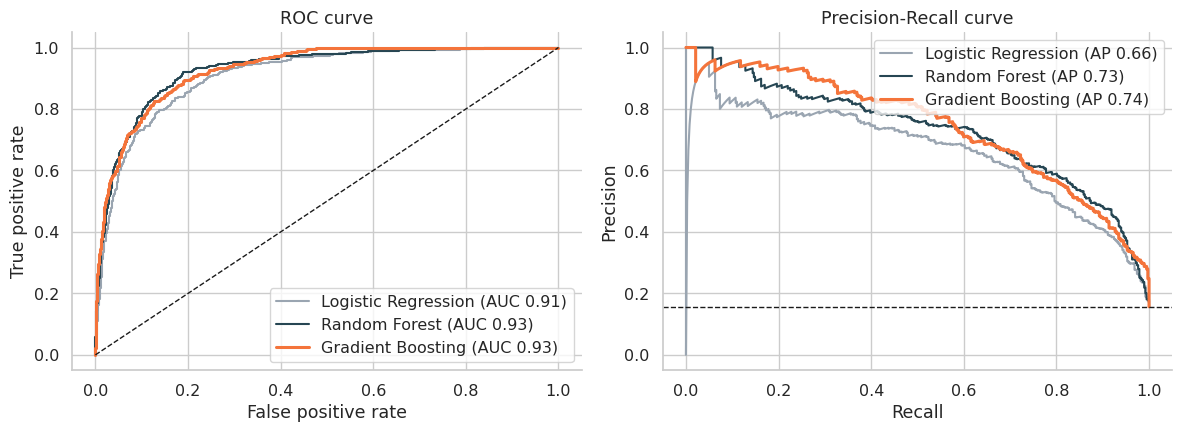

💡 Gradient Boosting: 5-fold cross-validated ROC-AUC = 0.928 (± 0.007), so the result is stable and not a lucky split.


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
pal = {"Logistic Regression": GREY, "Random Forest": NAVY, "Gradient Boosting": ORANGE}
for name, p in probs.items():
    fpr, tpr, _ = roc_curve(y_test, p)
    axes[0].plot(fpr, tpr, color=pal[name], lw=2.2 if name == BEST else 1.5, label=f"{name} (AUC {roc_auc_score(y_test, p):.2f})")
    pr, rc, _ = precision_recall_curve(y_test, p)
    axes[1].plot(rc, pr, color=pal[name], lw=2.2 if name == BEST else 1.5, label=f"{name} (AP {average_precision_score(y_test, p):.2f})")
axes[0].plot([0, 1], [0, 1], "k--", lw=1); axes[0].set_title("ROC curve"); axes[0].set_xlabel("False positive rate"); axes[0].set_ylabel("True positive rate"); axes[0].legend(loc="lower right")
axes[1].axhline(y_test.mean(), color="k", ls="--", lw=1); axes[1].set_title("Precision-Recall curve"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision"); axes[1].legend(loc="upper right")
sns.despine(); plt.tight_layout(); plt.show()

cv = StratifiedKFold(5, shuffle=True, random_state=42)
cv_auc = cross_val_score(models[BEST], X, y, cv=cv, scoring="roc_auc")
print(f"💡 {BEST}: 5-fold cross-validated ROC-AUC = {cv_auc.mean():.3f} (± {cv_auc.std():.3f}), so the result is stable and not a lucky split.")

### What we see
- All three models are strong (ROC-AUC about **0.91 to 0.93**), and the two tree-based models beat the simple Logistic Regression baseline on PR-AUC, which is the metric that matters for imbalanced data.
- **Why PR-AUC and recall, not accuracy?** With 84% non-buyers, accuracy is misleading. We care about *how many real buyers we catch* (recall) and *how clean our list is* (precision).
- Cross-validation confirms the score is stable, so the model is not just lucky on one split.

## 6. From model to business value: lift and lead tiers

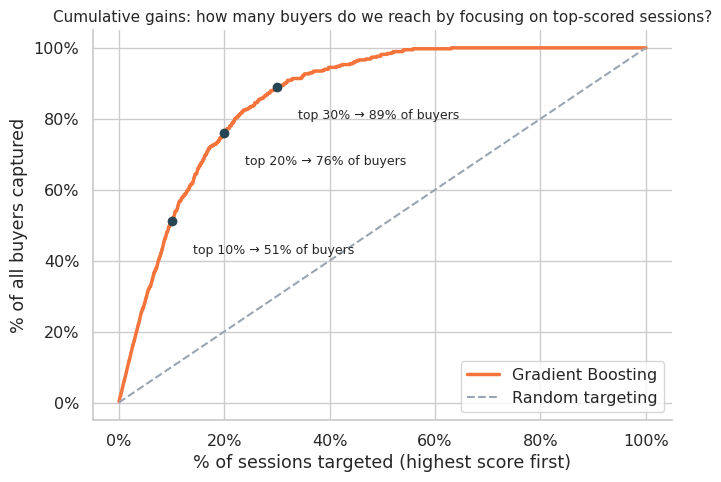

💡 Focusing on just the top 20% of scored sessions captures 76% of all buyers (3.8x better than random).


In [12]:
p_best = probs[BEST]
order_idx = np.argsort(-p_best)
y_sorted = y_test.values[order_idx]
cum_buyers = np.cumsum(y_sorted) / y_sorted.sum()
pct_sessions = np.arange(1, len(y_sorted) + 1) / len(y_sorted)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(pct_sessions, cum_buyers, color=ORANGE, lw=2.5, label=f"{BEST}")
ax.plot([0, 1], [0, 1], color=GREY, ls="--", label="Random targeting")
for q in (0.1, 0.2, 0.3):
    v = cum_buyers[int(q * len(y_sorted)) - 1]
    ax.scatter([q], [v], color=NAVY, zorder=5); ax.annotate(f"top {q:.0%} → {v:.0%} of buyers", (q, v), xytext=(q + 0.04, v - 0.09), fontsize=9)
ax.set_title("Cumulative gains: how many buyers do we reach by focusing on top-scored sessions?")
ax.title.set_fontsize(11)
ax.set_xlabel("% of sessions targeted (highest score first)"); ax.set_ylabel("% of all buyers captured")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(loc="lower right"); sns.despine(); plt.tight_layout(); plt.show()

top20 = cum_buyers[int(0.2 * len(y_sorted)) - 1]
print(f"💡 Focusing on just the top 20% of scored sessions captures {top20:.0%} of all buyers ({top20/0.2:.1f}x better than random).")

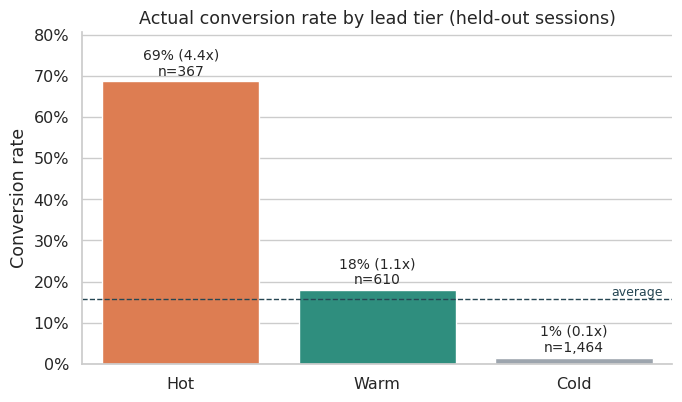

💡 'Hot' sessions convert at 69% vs 1.4% for 'Cold': a 48x gap that a team can act on.


In [13]:
# Hot / Warm / Cold tiers by score percentile on the held-out test set
hot_cut, warm_cut = np.quantile(p_best, 0.85), np.quantile(p_best, 0.60)
tier = np.where(p_best >= hot_cut, "Hot", np.where(p_best >= warm_cut, "Warm", "Cold"))
tiers = (pd.DataFrame({"tier": tier, "bought": y_test.values}).groupby("tier")["bought"].agg(["mean", "size"])
         .reindex(["Hot", "Warm", "Cold"]))
tiers["lift"] = tiers["mean"] / y_test.mean()

fig, ax = plt.subplots(figsize=(7, 4.2))
sns.barplot(x=tiers.index, y=tiers["mean"], palette=[ORANGE, TEAL, GREY], ax=ax)
ax.axhline(y_test.mean(), color=NAVY, ls="--", lw=1); ax.text(2.45, y_test.mean() + 0.01, "average", ha="right", color=NAVY, fontsize=9)
for i, (m, n, l) in enumerate(zip(tiers["mean"], tiers["size"], tiers["lift"])):
    ax.text(i, m + 0.015, f"{m:.0%} ({l:.1f}x)\nn={n:,}", ha="center", fontsize=10)
ax.set_title("Actual conversion rate by lead tier (held-out sessions)"); ax.set_xlabel(""); ax.set_ylabel("Conversion rate")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0)); ax.set_ylim(0, tiers["mean"].max() + 0.12)
sns.despine(); plt.tight_layout(); plt.show()

print(f"💡 'Hot' sessions convert at {tiers.loc['Hot','mean']:.0%} vs {tiers.loc['Cold','mean']:.1%} for 'Cold': "
      f"a {tiers.loc['Hot','mean']/max(tiers.loc['Cold','mean'],1e-9):.0f}x gap that a team can act on.")

### What we see
- The **gains curve** shows the model is far better than random targeting: a small slice of top-scored sessions contains a large share of all buyers.
- The **tier chart** is the most product-friendly view: Hot sessions convert at several times the average, Cold sessions barely convert. That gap is what lets a business **prioritise effort** (sales follow-up, notifications, matching) by tier.

## 7. Why does the model decide this? (Explainability)

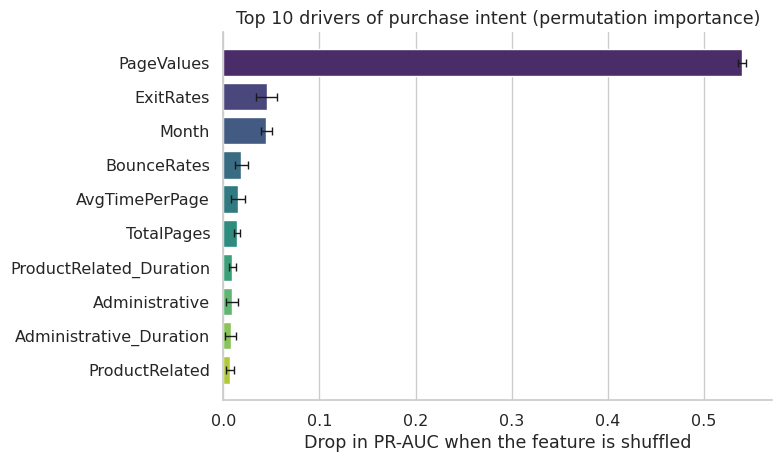

💡 Top 3 drivers: PageValues, ExitRates, Month


In [14]:
imp = permutation_importance(models[BEST], X_test, y_test, scoring="average_precision",
                             n_repeats=5, random_state=42, n_jobs=-1)
imp_df = (pd.DataFrame({"feature": X_test.columns, "importance": imp.importances_mean, "std": imp.importances_std})
          .sort_values("importance", ascending=False).head(10))

plt.figure(figsize=(8, 4.8))
sns.barplot(data=imp_df, x="importance", y="feature", palette="viridis")
plt.errorbar(imp_df["importance"], range(len(imp_df)), xerr=imp_df["std"], fmt="none", ecolor="k", lw=1, capsize=3)
plt.title("Top 10 drivers of purchase intent (permutation importance)")
plt.xlabel("Drop in PR-AUC when the feature is shuffled"); plt.ylabel("")
sns.despine(); plt.tight_layout(); plt.show()
print("💡 Top 3 drivers:", ", ".join(imp_df["feature"].head(3)))

### What we see
**Permutation importance** shuffles one feature at a time and measures how much model quality drops, so it works for any model and is easy to explain to non-technical stakeholders. `PageValues` dominates, followed by exit-related and seasonal (month) signals. Behavioural signals matter far more than technical ones such as browser or operating system.

In [15]:
# ─── Lead scorecard: score from the best model, plain-English reasons from the interpretable Logistic Regression ───
lr = models["Logistic Regression"]
pre_fit = lr.named_steps["columntransformer"]
coefs = lr.named_steps["logisticregression"].coef_[0]
feat_names = [n.split("__", 1)[1] for n in pre_fit.get_feature_names_out()]

SKIP = ("Region", "Browser", "OperatingSystems", "TrafficType")   # technical codes: not meaningful as reasons
def reasons(row_df, k=3):
    z = pre_fit.transform(row_df)[0]
    contrib = z * coefs
    out = []
    for i in np.argsort(-contrib):
        name = feat_names[i]
        if contrib[i] <= 0 or name.startswith(SKIP):
            continue
        if name.split("_")[0] in cat_cols:                 # one-hot flag that is switched on
            out.append(name.replace("_", "=", 1))
        elif name == "IsReturning":
            out.append("returning visitor" if z[i] > 0 else "new visitor")
        elif name == "Weekend":
            out.append("weekend visit" if z[i] > 0 else "weekday visit")
        else:                                              # numeric feature: show direction vs average
            out.append(("high " if z[i] > 0 else "low ") + name)
        if len(out) == k:
            break
    return "; ".join(out)

rng = np.random.RandomState(7)
picks = []
for t in ["Hot", "Hot", "Warm", "Warm", "Cold", "Cold"]:
    idx = np.where(tier == t)[0]
    picks.append(rng.choice(idx))

card = pd.DataFrame({
    "Session": [f"#{X_test.index[i]}" for i in picks],
    "Intent score": [p_best[i] for i in picks],
    "Tier": [tier[i] for i in picks],
    "Top reasons (what pushed the score up)": [reasons(X_test.iloc[[i]]) for i in picks],
    "Actually bought?": ["Yes" if y_test.values[i] == 1 else "No" for i in picks],
})
card["Intent score"] = card["Intent score"].round(2)
card

,Session,Intent score,Tier,Top reasons (what pushed the score up),Actually bought?
0,#11260,0.98,Hot,high PageValues; Month=Nov; low ExitRates,Yes
1,#3393,0.86,Hot,high PageValues; weekend visit; low Administra...,No
2,#11925,0.40,Warm,Month=Nov; low ExitRates; low Administrative_D...,No
3,#7229,0.25,Warm,low ExitRates; Month=Aug; weekend visit,Yes
4,#3673,0.00,Cold,low ExitRates; low Administrative_Duration; re...,No
5,#4778,0.00,Cold,low ExitRates; high Informational; high Admini...,No


### What we see
This is a **prototype lead scorecard**: every session gets an intent score, a Hot/Warm/Cold tier and the top reasons behind it. The reasons matter because sellers, sales teams and product managers trust and act on scores they can understand.

## 8. Product recommendations (what I would ship)

| # | Insight from the data | Product action | Metric to move |
|---|---|---|---|
| 1 | Hot-tier sessions convert at several times the average | Route Hot buyers to the best-matched sellers first and trigger instant follow-up | Lead-to-conversion rate, seller response time |
| 2 | Deep, low-exit browsers are the best segment; high-exit visitors rarely convert | Offer guided help (search assist, comparison, quick enquiry) to deep browsers who haven't acted | Enquiry rate, sessions-to-enquiry |
| 3 | Returning visitors convert less than new ones | Personalised re-engagement for returning browsers (saved searches, price/stock nudges) | Returning-visitor conversion |
| 4 | Strong seasonality (Nov peak) | Scale seller capacity and campaigns ahead of peak months | Conversion in peak vs off-peak |
| 5 | Cold tier barely converts | Avoid spending notifications and seller effort on Cold sessions | Cost per converted lead |

**How I would test it:** an A/B test where treatment buyers get tier-based routing and control gets the current flow. **Primary metric:** conversion rate of routed leads. **Guardrails:** buyer experience (complaints, bounce) and seller-side lead quality ratings.

## 9. Limitations and next steps
- **Proxy data:** this is a single retail site's B2C sessions, not B2B marketplace data. The method transfers; the exact numbers would not.
- **`PageValues` availability:** it is derived from past transactions, so a live system must make sure it is computed without using the current session's outcome (potential data leakage).
- **Imbalanced classes:** `class_weight="balanced"` improves recall but shifts predicted probabilities, so scores should be **calibrated** before being read as literal probabilities.
- **Single train/test split plus cross-validation:** no time-based split, even though the data covers 10 months. Next step: validate on later months.
- **Next steps:** probability calibration, a time-based validation, hyper-parameter tuning, and SHAP for per-session explanations.